In [1]:
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.utils import * 
from aqua.plotting_functions import *
from aqua.stimulus import OU_current

'''general imports''' 
import numpy as np
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import seaborn as sns
import pyspike as spk
import pickle
import gc
import tracemalloc
from scipy.signal import convolve, windows
from scipy.stats import wasserstein_distance
from scipy.ndimage import gaussian_filter

from FT_metrics import *
from functions import *

WARNING    /home/liam/anaconda3/envs/aqua/lib/python3.14/site-packages/pyspike/__init__.py:40: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
 [py.warnings]


In [2]:
tag = 'test200'
filename = f"burst_analysis_{tag}TRACES.pickle"
with open(filename, 'rb') as file:
    data = pickle.load(file)

print(data.keys())

time = data['time']
N_iter = len(time)
print(N_iter)
dt = time[1] - time[0]
T = N_iter * dt

f_vals = data['f']

spikes_E1 = data['spikes_E1']
spikes_E2 = data['spikes_E2']

bin1 = binarise_spikes(spikes_E1, dt, N_iter)
bin2 = binarise_spikes(spikes_E2, dt, N_iter)

# Autapse values to inspect

idx_0 = np.argmin(np.abs(f_vals - 0.))
idx_100 = np.argmin(np.abs(f_vals - 100.))
idx_250 = np.argmin(np.abs(f_vals - 250.))
idx_272 = np.argmin(np.abs(f_vals - 272.))
idx_350 = np.argmin(np.abs(f_vals - 350.))
idx_445 = np.argmin(np.abs(f_vals - 445.))

f_values = np.array([0, 100, 250, 272, 350, 445])
idx_arr = np.array([idx_0, idx_100, idx_250, idx_272, idx_350, idx_445])



dict_keys(['e', 'f', 'tau', 'time', 'X_E1', 'X_E2', 'I_E1', 'I_E2', 'spikes_E1', 'spikes_E2'])
50000


In [3]:
## First test the van Rossum distance for different time constants
# Compare different time constants
# filter for each row, calculate rolling vR distance

window = 500
tau_decays = np.linspace(5, 100, 10)

VR_dict = {}
for i, tau in enumerate(tau_decays):
    # create the filter
    T_filter = 7 * tau
    filter_length = int(T_filter/dt)
    filter = np.exp(-np.linspace(0, T_filter, filter_length)/tau)

    # create filtered arrays
    rollVR = np.zeros((len(f_vals[idx_arr]), N_iter))

    for n, f in enumerate(f_vals[idx_arr]):
        rollVR[n] = rolling_VR_dist(bin1[n], bin2[n], filter, window = window)

    VR_dict[tau] = rollVR



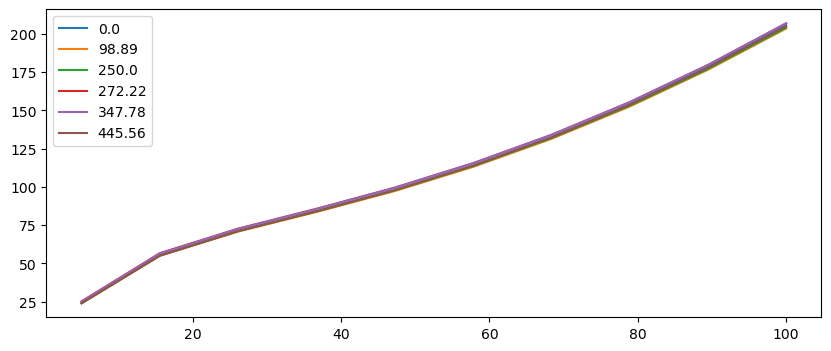

In [4]:
# plot the VR distances for the select autapse indices...

avg_distance = np.zeros((len(idx_arr), len(tau_decays)))

#fig, ax = plt.subplots(len(tau_decays), 1, figsize = (10, 3*len(tau_decays)))

for i, tau in enumerate(tau_decays):
    #ax[i].set_title(f'Decay: {tau}')
    
    distance = np.zeros(len(idx_arr))
    for j, f in enumerate(f_vals[idx_arr]):
        #ax[i].plot(VR_dict[tau][idx, :], label = f_values[j])
        avg_distance[j, i] = np.mean(VR_dict[tau][j, -10000:])
    
fig, ax = plt.subplots(1, 1, figsize = (10, 4))
for i in range(len(idx_arr)):

    ax.plot(tau_decays, avg_distance[i, :], label = np.round(f_vals[idx_arr[i]], 2))

ax.legend()



In [5]:
## Now Test the schreiber similarity...idx_0 = np.argmin(np.abs(f_vals - 0.))

window = 500
tau_decays = np.linspace(0.5, 50, 20)
print(tau_decays)

schreib_dict = {}
for i, tau in enumerate(tau_decays):

    # create filtered arrays
    rollSchreib = np.zeros((len(f_vals[idx_arr]), N_iter))

    for n, f in enumerate(f_vals[idx_arr]):
        #print(f"F: {f} pA")
        rollSchreib[n] = rolling_schreiber(bin1[n], bin2[n], sigma = tau, dt = dt, window = window)

    schreib_dict[tau] = rollSchreib



[ 0.5         3.10526316  5.71052632  8.31578947 10.92105263 13.52631579
 16.13157895 18.73684211 21.34210526 23.94736842 26.55263158 29.15789474
 31.76315789 34.36842105 36.97368421 39.57894737 42.18421053 44.78947368
 47.39473684 50.        ]


Text(0, 0.5, 'Achieved Schreiber similarity')

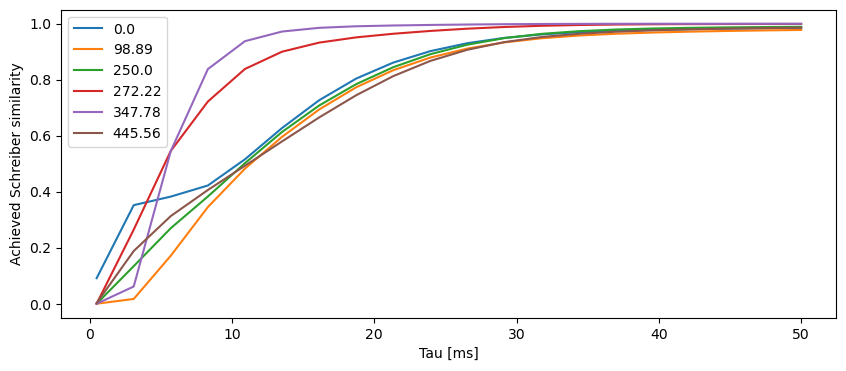

In [6]:
f_values = np.array([0, 100, 250, 272, 350, 445])
idx_arr = np.array([idx_0, idx_100, idx_250, idx_272, idx_350, idx_445])

avg_similarity = np.zeros((len(idx_arr), len(tau_decays)))

#fig, ax = plt.subplots(len(tau_decays), 1, figsize = (10, 3*len(tau_decays)))

for i, tau in enumerate(tau_decays):
    #ax[i].set_title(f'Decay: {tau}')
    
    distance = np.zeros(len(idx_arr))
    for j, idx in enumerate(idx_arr):
        #ax[i].plot(VR_dict[tau][idx, :], label = f_values[j])
        #avg_similarity[j, i] = np.mean(schreib_dict[tau][j, -10000:])
        avg_similarity[j, i] = schreiber_similarity(bin1[idx][-10000:], bin2[idx][-10000:], tau, dt)
    
fig, ax = plt.subplots(1, 1, figsize = (10, 4))
for i in range(len(idx_arr)):

    ax.plot(tau_decays, avg_similarity[i, :], label = np.round(f_vals[idx_arr[i]], 2))

ax.legend()
ax.set_xlabel('Tau [ms]')
ax.set_ylabel('Achieved Schreiber similarity')


[ 0.5         3.10526316  5.71052632  8.31578947 10.92105263 13.52631579
 16.13157895 18.73684211 21.34210526 23.94736842 26.55263158 29.15789474
 31.76315789 34.36842105 36.97368421 39.57894737 42.18421053 44.78947368
 47.39473684 50.        ]
0.9813918200712313
SCHREIBER: 0.6541811639896664
50000


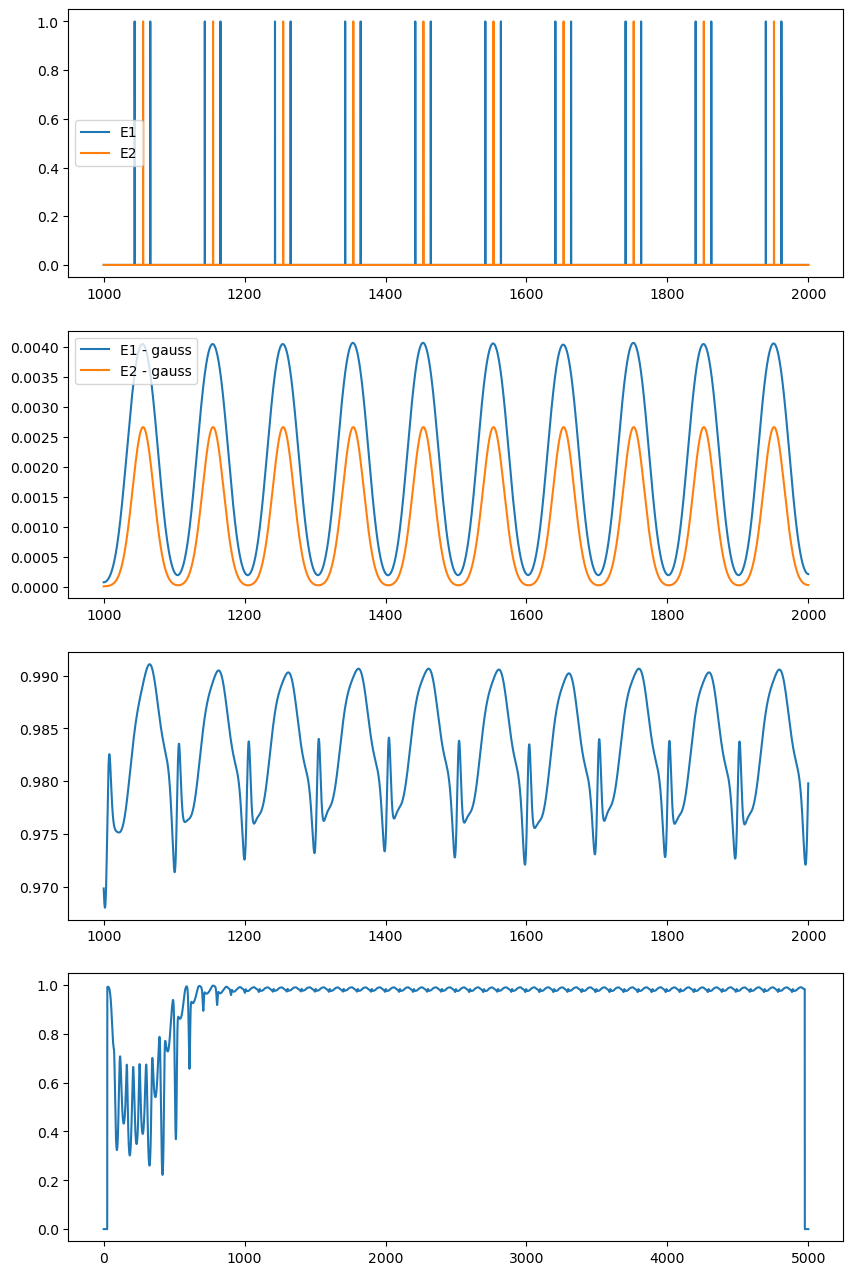

In [12]:
## Test rolling schreiber metric here
print(tau_decays)
idx = idx_350
#idx = idx_0
#idx = idx_100
#idx = idx_445
sigma = 15 # ms?

fig, ax = plt.subplots(4, 1, figsize = (10, 16))
window = 500
split = np.arange(10000, 20000, 1)
#split = np.arange(38700, 46800, 1)

ax[0].plot(time[split], bin1[idx][split], label = 'E1')
ax[0].plot(time[split], bin2[idx][split], label = 'E2')
ax[0].legend()

# smooth with gaussian
gauss1 = gaussian_filter(bin1[idx][split], sigma = sigma/dt)
gauss2 = gaussian_filter(bin2[idx][split], sigma = sigma/dt)
print(np.dot(gauss1, gauss2)/(np.linalg.norm(gauss1)*np.linalg.norm(gauss2)))

ax[1].plot(time[split], gauss1, label = 'E1 - gauss')
ax[1].plot(time[split], gauss2, label = 'E2 - gauss')
ax[1].legend()

print(f'SCHREIBER: {schreiber_similarity(bin1[0][split], bin2[0][split], sigma, dt)}')

# schreiber similarity
print(len(bin1[0]))
roll1 = rolling_schreiber(bin1[idx], bin2[idx], sigma = sigma, dt = dt, window = window)
ax[2].plot(time[split], roll1[split], label = 'rolling schreiber similarity')

ax[3].plot(time, roll1, label = 'rolling schreiber similarity')



In [13]:
print(f'SCHREIBER 0: {schreiber_similarity(bin1[idx_0], bin2[idx_0], sigma, dt)}')

print(f'SCHREIBER 350: {schreiber_similarity(bin1[idx_350], bin2[idx_350], sigma, dt)}')

SCHREIBER 0: 0.7014775183486971
SCHREIBER 350: 0.9313229793093007
